In [1]:
pip install pandas numpy matplotlib scipy statsmodels openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.3/20.3 MB 36.2 MB/s  0:00:00m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 44.1 MB/s  0:00:00m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [statsmodels] [statsmodels]
Note: you may need to restart the kernel to use updated packages.



=== Summary ===
                          Metric       Value
0              Total predictions         479
1            Correct predictions         250
2                 Final accuracy    0.521921
3                     95% CI low    0.477191
4                    95% CI high    0.566302
5   Binomial test p-value vs 50%    0.360824
6         First 120 obs accuracy    0.558333
7         First 240 obs accuracy      0.5125
8         First 360 obs accuracy    0.486111
9           Last 60 obs accuracy    0.666667
10         Last 120 obs accuracy    0.633333
11            Latest signal date  2026-03-10
12    Latest predicted direction        DOWN
13                  Latest score         0.0

=== Final Evaluation ===
전체 예측 수: 479
정답 수: 250
최종 정답률: 52.1921%
95% 신뢰구간: [47.7191%, 56.6302%]
50% 대비 이항검정 p-value: 0.360824
=> 50%보다 유의하게 다르다고 보기 어렵습니다.

=== Latest Signal ===
기준일: 2026-03-10
signal_score: 0.0
예측 방향: DOWN


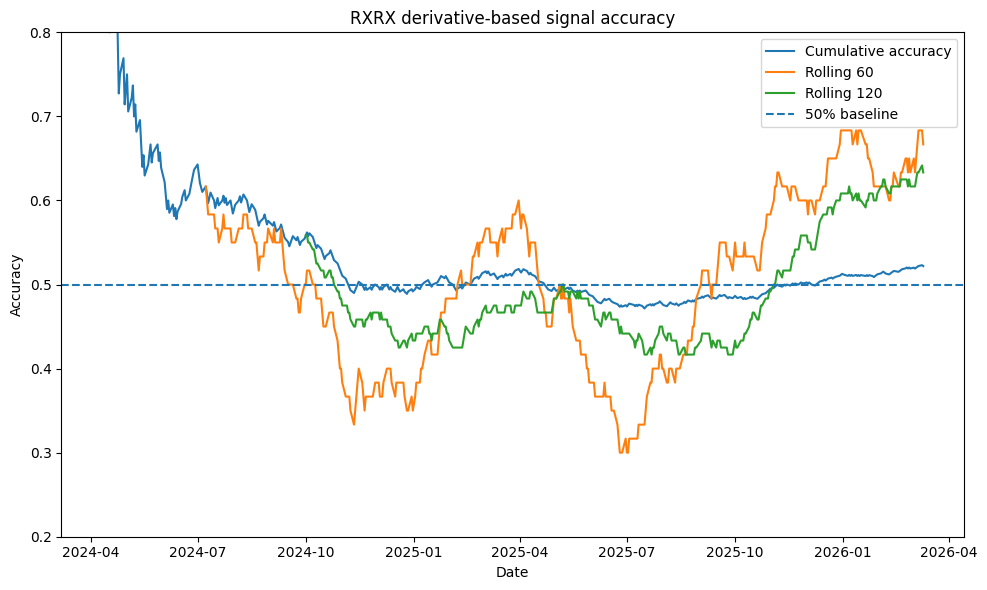

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportion_confint
from scipy.stats import binomtest

# =========================
# 1) 데이터 불러오기
# =========================
path = "RXRX_stock_with_indicators.csv"  # 파일 경로에 맞게 수정
df = pd.read_csv(path)

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

# =========================
# 2) 미분 기반 시그널 생성
# =========================
# 이번 규칙:
# - 5일 이동평균의 2차 차분(가속도 유사)
# - 20일 이동평균의 2차 차분(가속도 유사)
# - 두 부호의 합으로 시그널 점수 생성
#
# score > 0  -> 다음 날 상승 예측
# score <= 0 -> 다음 날 하락 예측
#
# 주의:
# 실제 미분은 연속시간 개념이지만,
# 주가 데이터에서는 차분(diff)으로 근사합니다.

df["ma5_acc"] = df["MA_5"].diff().diff()
df["ma20_acc"] = df["MA_20"].diff().diff()

df["signal_score"] = np.sign(df["ma5_acc"]).fillna(0) + np.sign(df["ma20_acc"]).fillna(0)

df["Prediction"] = np.where(df["signal_score"] > 0, "UP", "DOWN")

# =========================
# 3) 실제 다음 날 방향 계산
# =========================
df["Next_Close"] = df["Close"].shift(-1)
df["Actual"] = np.where(df["Next_Close"] > df["Close"], "UP", "DOWN")

# 마지막 행은 다음 날 종가가 없으므로 제외
valid = (
    df["ma5_acc"].notna()
    & df["ma20_acc"].notna()
    & df["Next_Close"].notna()
)

result = df.loc[
    valid,
    [
        "Date",
        "Close",
        "MA_5",
        "MA_20",
        "ma5_acc",
        "ma20_acc",
        "signal_score",
        "Prediction",
        "Next_Close",
        "Actual",
    ],
].copy()

# =========================
# 4) O/X 및 정답률 계산
# =========================
result["OX"] = np.where(result["Prediction"] == result["Actual"], "O", "X")
result["Correct"] = (result["OX"] == "O").astype(int)

# 누적 정답률
result["Cumulative_Accuracy"] = result["Correct"].cumsum() / np.arange(1, len(result) + 1)

# 롤링 정답률
result["Rolling_60_Accuracy"] = result["Correct"].rolling(60).mean()
result["Rolling_120_Accuracy"] = result["Correct"].rolling(120).mean()

# =========================
# 5) 전체 성능 요약
# =========================
n = len(result)
k = int(result["Correct"].sum())
acc = k / n

# 95% 신뢰구간 (Wilson)
ci_low, ci_high = proportion_confint(k, n, alpha=0.05, method="wilson")

# 50%와 유의하게 다른지 검정
p_value = binomtest(k, n, 0.5, alternative="two-sided").pvalue

# 구간별 정확도
first_120_acc = result["Correct"].iloc[:120].mean() if n >= 120 else np.nan
first_240_acc = result["Correct"].iloc[:240].mean() if n >= 240 else np.nan
first_360_acc = result["Correct"].iloc[:360].mean() if n >= 360 else np.nan

last_60_acc = result["Correct"].iloc[-60:].mean() if n >= 60 else np.nan
last_120_acc = result["Correct"].iloc[-120:].mean() if n >= 120 else np.nan

summary = pd.DataFrame({
    "Metric": [
        "Total predictions",
        "Correct predictions",
        "Final accuracy",
        "95% CI low",
        "95% CI high",
        "Binomial test p-value vs 50%",
        "First 120 obs accuracy",
        "First 240 obs accuracy",
        "First 360 obs accuracy",
        "Last 60 obs accuracy",
        "Last 120 obs accuracy",
        "Latest signal date",
        "Latest predicted direction",
        "Latest score",
    ],
    "Value": [
        n,
        k,
        acc,
        ci_low,
        ci_high,
        p_value,
        first_120_acc,
        first_240_acc,
        first_360_acc,
        last_60_acc,
        last_120_acc,
        result["Date"].iloc[-1].date().isoformat(),
        result["Prediction"].iloc[-1],
        result["signal_score"].iloc[-1],
    ]
})

# =========================
# 6) 결과 출력
# =========================
print("\n=== Summary ===")
print(summary)

print("\n=== Final Evaluation ===")
print(f"전체 예측 수: {n}")
print(f"정답 수: {k}")
print(f"최종 정답률: {acc:.4%}")
print(f"95% 신뢰구간: [{ci_low:.4%}, {ci_high:.4%}]")
print(f"50% 대비 이항검정 p-value: {p_value:.6f}")

if p_value < 0.05:
    print("=> 50%보다 유의하게 다릅니다.")
else:
    print("=> 50%보다 유의하게 다르다고 보기 어렵습니다.")

# =========================
# 7) 최신 예측 방향 출력
# =========================
latest_row = result.iloc[-1]
print("\n=== Latest Signal ===")
print(f"기준일: {latest_row['Date'].date()}")
print(f"signal_score: {latest_row['signal_score']}")
print(f"예측 방향: {latest_row['Prediction']}")

# =========================
# 8) 차트 그리기
# =========================
plt.figure(figsize=(10, 6))
plt.plot(result["Date"], result["Cumulative_Accuracy"], label="Cumulative accuracy")
plt.plot(result["Date"], result["Rolling_60_Accuracy"], label="Rolling 60")
plt.plot(result["Date"], result["Rolling_120_Accuracy"], label="Rolling 120")
plt.axhline(0.5, linestyle="--", label="50% baseline")

plt.xlabel("Date")
plt.ylabel("Accuracy")
plt.title("RXRX derivative-based signal accuracy")
plt.ylim(0.2, 0.8)
plt.legend()
plt.tight_layout()
plt.show()

# =========================
# 9) CSV/엑셀 저장 (선택)
# =========================
result.to_csv("RXRX_derivative_signal_results.csv", index=False)

with pd.ExcelWriter("RXRX_derivative_signal_results.xlsx", engine="openpyxl") as writer:
    result.to_excel(writer, index=False, sheet_name="Signals")
    summary.to_excel(writer, index=False, sheet_name="Summary")

In [4]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mplfinance as mpf

from scipy.stats import binomtest
from statsmodels.stats.proportion import proportion_confint

In [5]:
# 기본 보조지표 함수
def calculate_rsi(close: pd.Series, period: int = 14) -> pd.Series:
    delta = close.diff()

    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    avg_gain = gain.ewm(alpha=1 / period, min_periods=period, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1 / period, min_periods=period, adjust=False).mean()

    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi


def calculate_atr(df: pd.DataFrame, period: int = 14) -> pd.Series:
    high = df["High"]
    low = df["Low"]
    close = df["Close"]

    prev_close = close.shift(1)

    tr1 = high - low
    tr2 = (high - prev_close).abs()
    tr3 = (low - prev_close).abs()

    tr = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)
    atr = tr.rolling(period).mean()
    return atr


def calculate_macd(close: pd.Series, fast: int = 12, slow: int = 26, signal: int = 9):
    ema_fast = close.ewm(span=fast, adjust=False).mean()
    ema_slow = close.ewm(span=slow, adjust=False).mean()

    macd = ema_fast - ema_slow
    macd_signal = macd.ewm(span=signal, adjust=False).mean()
    macd_hist = macd - macd_signal

    return macd, macd_signal, macd_hist

In [6]:
# 지표 추가 함수
def add_indicators(df: pd.DataFrame) -> pd.DataFrame:
    result = df.copy()

    # 이동평균
    ma_periods = [5, 10, 20, 60, 120, 240]
    for period in ma_periods:
        result[f"MA_{period}"] = result["Close"].rolling(window=period).mean()

    # 볼린저밴드
    bb_period = 20
    bb_std = 2
    result["BB_MID"] = result["Close"].rolling(window=bb_period).mean()
    rolling_std = result["Close"].rolling(window=bb_period).std()
    result["BB_UPPER"] = result["BB_MID"] + (rolling_std * bb_std)
    result["BB_LOWER"] = result["BB_MID"] - (rolling_std * bb_std)

    # RSI
    result["RSI_14"] = calculate_rsi(result["Close"], period=14)

    # ATR
    result["ATR_14"] = calculate_atr(result, period=14)

    # MACD
    macd, macd_signal, macd_hist = calculate_macd(result["Close"])
    result["MACD"] = macd
    result["MACD_SIGNAL"] = macd_signal
    result["MACD_HIST"] = macd_hist

    # 기본 수익률
    result["Return_1D"] = result["Close"].pct_change()
    result["Log_Close"] = np.log(result["Close"])
    result["Log_Return_1D"] = result["Log_Close"].diff()

    # 거래량 정규화
    vol_mean_20 = result["Volume"].rolling(20).mean()
    vol_std_20 = result["Volume"].rolling(20).std()
    result["Volume_Z_20"] = (result["Volume"] - vol_mean_20) / vol_std_20

    return result

In [7]:
# 데이터 다운로드 함수
def get_stock_data(ticker: str, period: str = "3y", interval: str = "1d") -> pd.DataFrame:
    df = yf.download(
        ticker,
        period=period,
        interval=interval,
        auto_adjust=False,
        progress=False
    )

    if df.empty:
        raise ValueError(f"{ticker} 데이터가 비어 있습니다. 티커를 확인하세요.")

    if isinstance(df.columns, pd.MultiIndex):
        df.columns = [col[0] for col in df.columns]

    required_cols = ["Open", "High", "Low", "Close", "Volume"]
    missing = [col for col in required_cols if col not in df.columns]
    if missing:
        raise ValueError(f"{ticker} 필수 컬럼이 없습니다: {missing}")

    df = df[required_cols].copy()
    df.dropna(inplace=True)
    df.index.name = "Date"

    return df


def save_to_csv(df: pd.DataFrame, ticker: str, filename: str = None) -> str:
    if filename is None:
        filename = f"{ticker}_stock_with_indicators.csv"

    df.to_csv(filename, encoding="utf-8-sig")
    return filename

In [8]:
# 멀티 티커 수집
tickers = ["RXRX", "SDGR", "GLUE"]

stock_data = {}

for ticker in tickers:
    raw_df = get_stock_data(ticker=ticker, period="3y", interval="1d")
    df = add_indicators(raw_df)

    csv_file = save_to_csv(df, ticker)
    stock_data[ticker] = df

    print(f"[{ticker}] CSV 저장 완료: {csv_file}")
    print(df.tail(3))
    print("-" * 80)

[RXRX] CSV 저장 완료: RXRX_stock_with_indicators.csv
            Open  High   Low  Close    Volume   MA_5  MA_10   MA_20     MA_60  \
Date                                                                            
2026-03-10  3.49  3.57  3.40   3.44  10074000  3.518  3.597  3.5835  4.127833   
2026-03-11  3.44  3.56  3.34   3.45  14397900  3.480  3.565  3.5635  4.109000   
2026-03-12  3.36  3.39  3.22   3.29  18025573  3.430  3.517  3.5425  4.091667   

              MA_120  ...  BB_LOWER     RSI_14    ATR_14      MACD  \
Date                  ...                                            
2026-03-10  4.604917  ...  3.324086  39.647319  0.251071 -0.159242   
2026-03-11  4.594417  ...  3.330237  40.061497  0.246429 -0.156922   
2026-03-12  4.580750  ...  3.289945  35.825214  0.238571 -0.166080   

            MACD_SIGNAL  MACD_HIST  Return_1D  Log_Close  Log_Return_1D  \
Date                                                                      
2026-03-10    -0.175350   0.016108  -0.01994

In [9]:
def build_derivative_integral_features(df: pd.DataFrame) -> pd.DataFrame:
    x = df.copy()

    # 로그가격 기반
    x["log_close"] = np.log(x["Close"])

    # 1차 미분 근사: 속도(velocity)
    x["vel_1"] = x["log_close"].diff(1)
    x["vel_3"] = (x["log_close"] - x["log_close"].shift(3)) / 3
    x["vel_5"] = (x["log_close"] - x["log_close"].shift(5)) / 5

    # 2차 미분 근사: 가속도(acceleration)
    x["acc_1"] = x["vel_1"].diff(1)
    x["acc_3"] = x["vel_3"].diff(1)
    x["acc_5"] = x["vel_5"].diff(1)

    # 이동평균 기울기(추세 속도)
    x["ma5_slope"] = x["MA_5"].diff(1)
    x["ma20_slope"] = x["MA_20"].diff(1)
    x["ma60_slope"] = x["MA_60"].diff(1)

    # ATR 정규화
    atr = x["ATR_14"].replace(0, np.nan)
    x["ma5_slope_n"] = x["ma5_slope"] / atr
    x["ma20_slope_n"] = x["ma20_slope"] / atr
    x["ma60_slope_n"] = x["ma60_slope"] / atr

    # 적분 근사: 일정 기간 속도의 누적합 = 누적 모멘텀
    x["mom_int_3"] = x["vel_1"].rolling(3).sum()
    x["mom_int_5"] = x["vel_1"].rolling(5).sum()
    x["mom_int_10"] = x["vel_1"].rolling(10).sum()

    # 장단기 간격
    x["ma_gap_5_20"] = (x["MA_5"] - x["MA_20"]) / atr
    x["ma_gap_20_60"] = (x["MA_20"] - x["MA_60"]) / atr

    # 볼린저 위치
    band_width = (x["BB_UPPER"] - x["BB_LOWER"]).replace(0, np.nan)
    x["bb_position"] = (x["Close"] - x["BB_MID"]) / band_width

    # 다음날 실제 방향
    x["Next_Close"] = x["Close"].shift(-1)
    x["Actual"] = np.where(x["Next_Close"] > x["Close"], "UP", "DOWN")

    return x

In [10]:
def make_improved_signal(df: pd.DataFrame, threshold: float = 1.5) -> pd.DataFrame:
    x = df.copy()

    # 점수 구성
    # 1) 단기/중기 속도
    # 2) 가속도
    # 3) 누적 모멘텀(적분 근사)
    # 4) 장단기 추세 정렬
    # 5) RSI 과열/과매도 보정
    # 6) 거래량 동반 여부 소폭 반영

    x["score"] = 0.0

    # 속도
    x["score"] += 1.0 * np.sign(x["vel_3"])
    x["score"] += 1.0 * np.sign(x["vel_5"])

    # 가속도
    x["score"] += 0.7 * np.sign(x["acc_3"])
    x["score"] += 0.5 * np.sign(x["acc_5"])

    # 적분(누적 모멘텀)
    x["score"] += 1.0 * np.sign(x["mom_int_5"])
    x["score"] += 0.7 * np.sign(x["mom_int_10"])

    # 추세 정렬
    x["score"] += 0.7 * np.sign(x["ma5_slope_n"])
    x["score"] += 1.0 * np.sign(x["ma20_slope_n"])
    x["score"] += 1.2 * np.sign(x["ma60_slope_n"])

    # 장단기 간격
    x["score"] += 0.8 * np.sign(x["ma_gap_5_20"])
    x["score"] += 0.8 * np.sign(x["ma_gap_20_60"])

    # RSI 보정
    # 너무 과열이면 상승점수 약화, 과매도면 하락점수 약화
    x.loc[x["RSI_14"] >= 70, "score"] -= 1.0
    x.loc[x["RSI_14"] <= 30, "score"] += 1.0

    # 거래량 급증 시 신호 강화
    x.loc[x["Volume_Z_20"] >= 1.0, "score"] += 0.3 * np.sign(x["vel_3"])

    # HOLD 포함한 예측
    x["Prediction"] = np.select(
        [
            x["score"] >= threshold,
            x["score"] <= -threshold
        ],
        [
            "UP",
            "DOWN"
        ],
        default="HOLD"
    )

    return x

In [11]:
def evaluate_signal(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    x = df.copy()

    valid = x["Prediction"].isin(["UP", "DOWN"]) & x["Actual"].isin(["UP", "DOWN"])
    result = x.loc[valid].copy()

    result["OX"] = np.where(result["Prediction"] == result["Actual"], "O", "X")
    result["Correct"] = (result["OX"] == "O").astype(int)

    n_total = len(x.dropna(subset=["Actual"]))
    n_pred = len(result)
    coverage = n_pred / n_total if n_total > 0 else np.nan

    k = int(result["Correct"].sum())
    acc = k / n_pred if n_pred > 0 else np.nan

    if n_pred > 0:
        ci_low, ci_high = proportion_confint(k, n_pred, alpha=0.05, method="wilson")
        p_value = binomtest(k, n_pred, 0.5, alternative="two-sided").pvalue
    else:
        ci_low, ci_high, p_value = np.nan, np.nan, np.nan

    result["Cumulative_Accuracy"] = result["Correct"].cumsum() / np.arange(1, len(result) + 1)
    result["Rolling_50_Accuracy"] = result["Correct"].rolling(50).mean()
    result["Rolling_100_Accuracy"] = result["Correct"].rolling(100).mean()

    summary = pd.DataFrame({
        "Metric": [
            "Total rows with actual label",
            "Predicted rows (excluding HOLD)",
            "Coverage",
            "Correct predictions",
            "Accuracy",
            "95% CI low",
            "95% CI high",
            "Binomial p-value vs 50%",
            "Latest prediction date",
            "Latest prediction",
            "Latest score"
        ],
        "Value": [
            n_total,
            n_pred,
            coverage,
            k,
            acc,
            ci_low,
            ci_high,
            p_value,
            result.index[-1].date().isoformat() if n_pred > 0 else None,
            result["Prediction"].iloc[-1] if n_pred > 0 else None,
            result["score"].iloc[-1] if n_pred > 0 else None
        ]
    })

    return result, summary

In [12]:
all_results = {}
all_summaries = []

for ticker, df in stock_data.items():
    feat_df = build_derivative_integral_features(df)
    signal_df = make_improved_signal(feat_df, threshold=1.5)
    result_df, summary_df = evaluate_signal(signal_df)

    all_results[ticker] = {
        "features": feat_df,
        "signal": signal_df,
        "result": result_df,
        "summary": summary_df
    }

    summary_df = summary_df.copy()
    summary_df["Ticker"] = ticker
    all_summaries.append(summary_df)

    result_df.to_csv(f"{ticker}_improved_derivative_signal_results.csv", encoding="utf-8-sig")
    print(f"\n[{ticker}]")
    print(summary_df)


[RXRX]
                             Metric       Value Ticker
0      Total rows with actual label         753   RXRX
1   Predicted rows (excluding HOLD)         565   RXRX
2                          Coverage    0.750332   RXRX
3               Correct predictions         275   RXRX
4                          Accuracy    0.486726   RXRX
5                        95% CI low    0.445741   RXRX
6                       95% CI high     0.52789   RXRX
7           Binomial p-value vs 50%     0.55591   RXRX
8            Latest prediction date  2026-03-12   RXRX
9                 Latest prediction        DOWN   RXRX
10                     Latest score        -9.4   RXRX

[SDGR]
                             Metric       Value Ticker
0      Total rows with actual label         753   SDGR
1   Predicted rows (excluding HOLD)         587   SDGR
2                          Coverage    0.779548   SDGR
3               Correct predictions         286   SDGR
4                          Accuracy    0.487223  

In [13]:
summary_table = pd.concat(all_summaries, ignore_index=True)
summary_pivot = summary_table.pivot(index="Ticker", columns="Metric", values="Value")
summary_pivot

Metric,95% CI high,95% CI low,Accuracy,Binomial p-value vs 50%,Correct predictions,Coverage,Latest prediction,Latest prediction date,Latest score,Predicted rows (excluding HOLD),Total rows with actual label
Ticker,,,,,,,,,,,
GLUE,0.517249,0.434437,0.475676,0.269734,264,0.737052,DOWN,2026-03-12,-9.4,555,753
RXRX,0.52789,0.445741,0.486726,0.55591,275,0.750332,DOWN,2026-03-12,-9.4,565,753
SDGR,0.52761,0.447003,0.487223,0.563408,286,0.779548,DOWN,2026-03-12,-5.8,587,753


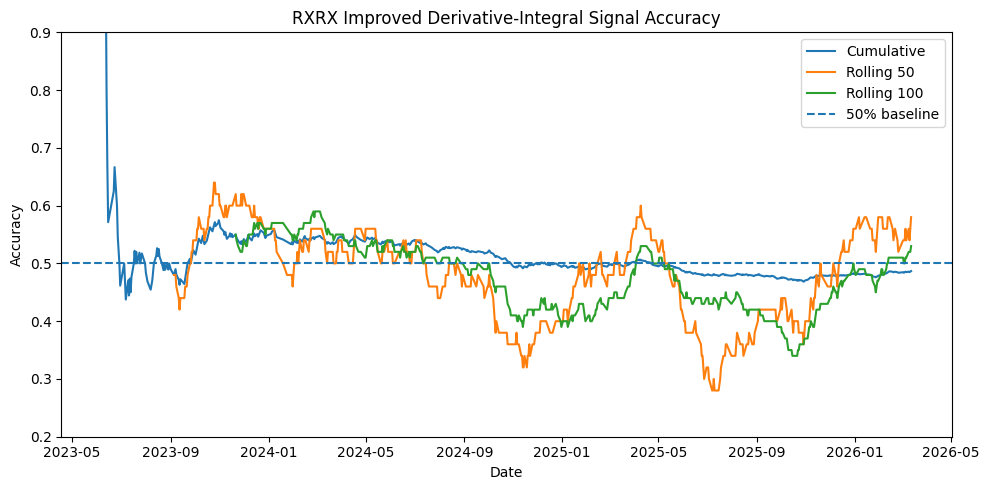

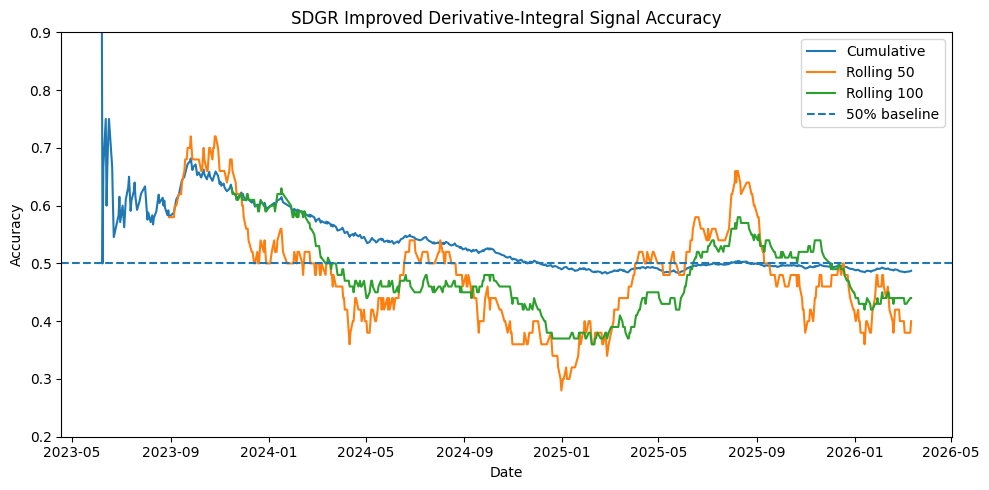

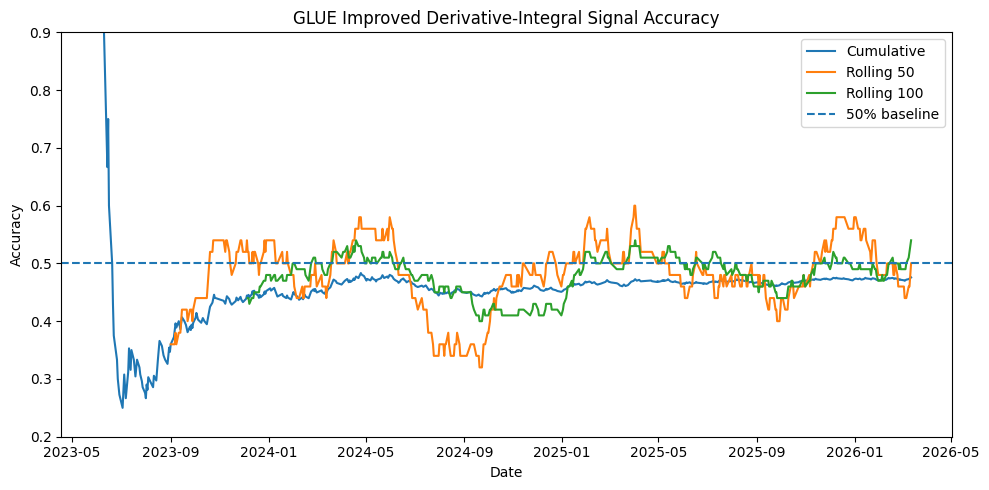

In [14]:
for ticker in tickers:
    result_df = all_results[ticker]["result"]

    if len(result_df) == 0:
        print(f"{ticker}: 예측 구간 없음")
        continue

    plt.figure(figsize=(10, 5))
    plt.plot(result_df.index, result_df["Cumulative_Accuracy"], label="Cumulative")
    plt.plot(result_df.index, result_df["Rolling_50_Accuracy"], label="Rolling 50")
    plt.plot(result_df.index, result_df["Rolling_100_Accuracy"], label="Rolling 100")
    plt.axhline(0.5, linestyle="--", label="50% baseline")

    plt.title(f"{ticker} Improved Derivative-Integral Signal Accuracy")
    plt.xlabel("Date")
    plt.ylabel("Accuracy")
    plt.ylim(0.2, 0.9)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [15]:
for ticker in tickers:
    signal_df = all_results[ticker]["signal"].copy()
    latest = signal_df.dropna(subset=["score"]).iloc[-1]

    print(f"\n[{ticker}]")
    print(f"Date       : {signal_df.index[-1].date()}")
    print(f"Close      : {latest['Close']:.2f}")
    print(f"Score      : {latest['score']:.2f}")
    print(f"Prediction : {latest['Prediction']}")
    print(f"RSI_14     : {latest['RSI_14']:.2f}")
    print(f"vel_3      : {latest['vel_3']:.5f}")
    print(f"acc_3      : {latest['acc_3']:.5f}")
    print(f"mom_int_5  : {latest['mom_int_5']:.5f}")


[RXRX]
Date       : 2026-03-12
Close      : 3.29
Score      : -9.40
Prediction : DOWN
RSI_14     : 35.83
vel_3      : -0.02158
acc_3      : -0.02061
mom_int_5  : -0.07324

[SDGR]
Date       : 2026-03-12
Close      : 12.16
Score      : -5.80
Prediction : DOWN
RSI_14     : 41.48
vel_3      : -0.02098
acc_3      : -0.02072
mom_int_5  : -0.06910

[GLUE]
Date       : 2026-03-12
Close      : 16.04
Score      : -9.40
Prediction : DOWN
RSI_14     : 33.05
vel_3      : -0.03207
acc_3      : -0.01792
mom_int_5  : -0.11250


In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import binomtest
from statsmodels.stats.proportion import proportion_confint

In [ ]:
def calculate_rsi(close: pd.Series, period: int = 14) -> pd.Series:
    delta = close.diff()

    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    avg_gain = gain.ewm(alpha=1 / period, min_periods=period, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1 / period, min_periods=period, adjust=False).mean()

    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi


def calculate_atr(df: pd.DataFrame, period: int = 14) -> pd.Series:
    high = df["High"]
    low = df["Low"]
    close = df["Close"]

    prev_close = close.shift(1)

    tr1 = high - low
    tr2 = (high - prev_close).abs()
    tr3 = (low - prev_close).abs()

    tr = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)
    atr = tr.rolling(period).mean()
    return atr


def calculate_macd(close: pd.Series, fast: int = 12, slow: int = 26, signal: int = 9):
    ema_fast = close.ewm(span=fast, adjust=False).mean()
    ema_slow = close.ewm(span=slow, adjust=False).mean()

    macd = ema_fast - ema_slow
    macd_signal = macd.ewm(span=signal, adjust=False).mean()
    macd_hist = macd - macd_signal

    return macd, macd_signal, macd_hist

In [ ]:
def add_indicators(df: pd.DataFrame) -> pd.DataFrame:
    result = df.copy()

    # 이동평균
    ma_periods = [5, 10, 20, 60, 120, 240]
    for period in ma_periods:
        result[f"MA_{period}"] = result["Close"].rolling(window=period).mean()

    # 볼린저밴드
    bb_period = 20
    bb_std = 2
    result["BB_MID"] = result["Close"].rolling(window=bb_period).mean()
    rolling_std = result["Close"].rolling(window=bb_period).std()
    result["BB_UPPER"] = result["BB_MID"] + (rolling_std * bb_std)
    result["BB_LOWER"] = result["BB_MID"] - (rolling_std * bb_std)

    # RSI
    result["RSI_14"] = calculate_rsi(result["Close"], period=14)

    # ATR
    result["ATR_14"] = calculate_atr(result, period=14)

    # MACD
    macd, macd_signal, macd_hist = calculate_macd(result["Close"])
    result["MACD"] = macd
    result["MACD_SIGNAL"] = macd_signal
    result["MACD_HIST"] = macd_hist

    # 기본 수익률
    result["Return_1D"] = result["Close"].pct_change()
    result["Log_Close"] = np.log(result["Close"])
    result["Log_Return_1D"] = result["Log_Close"].diff()

    # 거래량 정규화
    vol_mean_20 = result["Volume"].rolling(20).mean()
    vol_std_20 = result["Volume"].rolling(20).std()
    result["Volume_Z_20"] = (result["Volume"] - vol_mean_20) / vol_std_20

    return result

In [ ]:
def get_stock_data(
    ticker: str,
    period: str = None,
    start: str = None,
    end: str = None,
    interval: str = "1d"
) -> pd.DataFrame:
    """
    사용법 예시
    1) period 방식:
       get_stock_data("RXRX", period="3y", interval="1d")

    2) start/end 방식:
       get_stock_data("RXRX", start="2022-01-01", end="2025-12-31", interval="1d")
    """

    if period is not None:
        df = yf.download(
            ticker,
            period=period,
            interval=interval,
            auto_adjust=False,
            progress=False
        )
    else:
        df = yf.download(
            ticker,
            start=start,
            end=end,
            interval=interval,
            auto_adjust=False,
            progress=False
        )

    if df.empty:
        raise ValueError(f"{ticker} 데이터가 비어 있습니다. 기간 또는 티커를 확인하세요.")

    if isinstance(df.columns, pd.MultiIndex):
        df.columns = [col[0] for col in df.columns]

    required_cols = ["Open", "High", "Low", "Close", "Volume"]
    missing = [col for col in required_cols if col not in df.columns]
    if missing:
        raise ValueError(f"{ticker} 필수 컬럼이 없습니다: {missing}")

    df = df[required_cols].copy()
    df.dropna(inplace=True)
    df.index = pd.to_datetime(df.index)
    df.index.name = "Date"

    return df


def save_to_csv(df: pd.DataFrame, ticker: str, filename: str = None) -> str:
    if filename is None:
        filename = f"{ticker}_stock_with_indicators.csv"

    df.to_csv(filename, encoding="utf-8-sig")
    return filename

In [ ]:
def build_derivative_integral_features(df: pd.DataFrame, horizon: int = 3) -> pd.DataFrame:
    x = df.copy()

    # 로그가격
    x["log_close"] = np.log(x["Close"])

    # 1차 미분 근사: 속도
    x["vel_1"] = x["log_close"].diff(1)
    x["vel_3"] = (x["log_close"] - x["log_close"].shift(3)) / 3
    x["vel_5"] = (x["log_close"] - x["log_close"].shift(5)) / 5

    # 2차 미분 근사: 가속도
    x["acc_1"] = x["vel_1"].diff(1)
    x["acc_3"] = x["vel_3"].diff(1)
    x["acc_5"] = x["vel_5"].diff(1)

    # 이동평균 기울기
    x["ma5_slope"] = x["MA_5"].diff(1)
    x["ma20_slope"] = x["MA_20"].diff(1)
    x["ma60_slope"] = x["MA_60"].diff(1)

    # ATR 정규화
    atr = x["ATR_14"].replace(0, np.nan)
    x["ma5_slope_n"] = x["ma5_slope"] / atr
    x["ma20_slope_n"] = x["ma20_slope"] / atr
    x["ma60_slope_n"] = x["ma60_slope"] / atr

    # 적분 근사: 최근 모멘텀 누적합
    x["mom_int_3"] = x["vel_1"].rolling(3).sum()
    x["mom_int_5"] = x["vel_1"].rolling(5).sum()
    x["mom_int_10"] = x["vel_1"].rolling(10).sum()

    # 장단기 추세 간격
    x["ma_gap_5_20"] = (x["MA_5"] - x["MA_20"]) / atr
    x["ma_gap_20_60"] = (x["MA_20"] - x["MA_60"]) / atr

    # MACD 기울기
    x["macd_slope"] = x["MACD"].diff(1)
    x["macd_hist_slope"] = x["MACD_HIST"].diff(1)

    # 볼린저밴드 내 위치
    band_width = (x["BB_UPPER"] - x["BB_LOWER"]).replace(0, np.nan)
    x["bb_position"] = (x["Close"] - x["BB_MID"]) / band_width

    # ===== 향후 3거래일 타깃 =====
    x[f"Future_Close_{horizon}D"] = x["Close"].shift(-horizon)
    x[f"Forward_Return_{horizon}D"] = x[f"Future_Close_{horizon}D"] / x["Close"] - 1

    x["Actual"] = np.where(x[f"Forward_Return_{horizon}D"] > 0, "UP", "DOWN")

    return x

In [ ]:
def make_improved_signal(df: pd.DataFrame, threshold: float = 2.0) -> pd.DataFrame:
    x = df.copy()

    x["score"] = 0.0

    # 1) 속도
    x["score"] += 1.0 * np.sign(x["vel_3"])
    x["score"] += 1.0 * np.sign(x["vel_5"])

    # 2) 가속도
    x["score"] += 0.8 * np.sign(x["acc_3"])
    x["score"] += 0.6 * np.sign(x["acc_5"])

    # 3) 적분(누적 모멘텀)
    x["score"] += 1.0 * np.sign(x["mom_int_5"])
    x["score"] += 0.8 * np.sign(x["mom_int_10"])

    # 4) 이동평균 추세 정렬
    x["score"] += 0.8 * np.sign(x["ma5_slope_n"])
    x["score"] += 1.0 * np.sign(x["ma20_slope_n"])
    x["score"] += 1.2 * np.sign(x["ma60_slope_n"])

    # 5) 장단기 간격
    x["score"] += 0.8 * np.sign(x["ma_gap_5_20"])
    x["score"] += 0.8 * np.sign(x["ma_gap_20_60"])

    # 6) MACD 방향
    x["score"] += 0.6 * np.sign(x["macd_slope"])
    x["score"] += 0.6 * np.sign(x["macd_hist_slope"])

    # 7) RSI 보정
    x.loc[x["RSI_14"] >= 70, "score"] -= 1.0
    x.loc[x["RSI_14"] <= 30, "score"] += 1.0

    # 8) 거래량 급증 시 방향 강화
    x.loc[x["Volume_Z_20"] >= 1.0, "score"] += 0.4 * np.sign(x["vel_3"])

    # 최종 예측
    x["Prediction"] = np.select(
        [
            x["score"] >= threshold,
            x["score"] <= -threshold
        ],
        [
            "UP",
            "DOWN"
        ],
        default="HOLD"
    )

    return x

In [ ]:
def evaluate_signal(df: pd.DataFrame, horizon: int = 3) -> tuple[pd.DataFrame, pd.DataFrame]:
    x = df.copy()

    valid_actual = x["Actual"].isin(["UP", "DOWN"])
    valid_pred = x["Prediction"].isin(["UP", "DOWN"])

    result = x.loc[valid_actual & valid_pred].copy()

    result["OX"] = np.where(result["Prediction"] == result["Actual"], "O", "X")
    result["Correct"] = (result["OX"] == "O").astype(int)

    n_total = int(valid_actual.sum())   # 실제 라벨이 있는 전체 구간
    n_pred = len(result)                # HOLD 제외 실제 예측한 구간
    coverage = n_pred / n_total if n_total > 0 else np.nan

    k = int(result["Correct"].sum())
    acc = k / n_pred if n_pred > 0 else np.nan

    if n_pred > 0:
        ci_low, ci_high = proportion_confint(k, n_pred, alpha=0.05, method="wilson")
        p_value = binomtest(k, n_pred, 0.5, alternative="two-sided").pvalue
    else:
        ci_low, ci_high, p_value = np.nan, np.nan, np.nan

    result["Cumulative_Accuracy"] = result["Correct"].cumsum() / np.arange(1, len(result) + 1)
    result["Rolling_50_Accuracy"] = result["Correct"].rolling(50).mean()
    result["Rolling_100_Accuracy"] = result["Correct"].rolling(100).mean()

    summary = pd.DataFrame({
        "Metric": [
            "Total rows with actual label",
            "Predicted rows (excluding HOLD)",
            "Coverage",
            "Correct predictions",
            "Accuracy",
            "95% CI low",
            "95% CI high",
            "Binomial p-value vs 50%",
            "Last available prediction date",
            "Last available prediction",
            "Last available score"
        ],
        "Value": [
            n_total,
            n_pred,
            coverage,
            k,
            acc,
            ci_low,
            ci_high,
            p_value,
            result.index[-1].date().isoformat() if n_pred > 0 else None,
            result["Prediction"].iloc[-1] if n_pred > 0 else None,
            result["score"].iloc[-1] if n_pred > 0 else None
        ]
    })

    return result, summary

In [ ]:
def print_evaluation_report(ticker: str, result_df: pd.DataFrame, summary_df: pd.DataFrame, horizon: int = 3):
    summary_map = dict(zip(summary_df["Metric"], summary_df["Value"]))

    n_total = int(summary_map["Total rows with actual label"])
    n_pred = int(summary_map["Predicted rows (excluding HOLD)"])
    coverage = float(summary_map["Coverage"]) if pd.notna(summary_map["Coverage"]) else np.nan
    correct = int(summary_map["Correct predictions"])
    acc = float(summary_map["Accuracy"]) if pd.notna(summary_map["Accuracy"]) else np.nan
    ci_low = float(summary_map["95% CI low"]) if pd.notna(summary_map["95% CI low"]) else np.nan
    ci_high = float(summary_map["95% CI high"]) if pd.notna(summary_map["95% CI high"]) else np.nan
    p_value = float(summary_map["Binomial p-value vs 50%"]) if pd.notna(summary_map["Binomial p-value vs 50%"]) else np.nan
    last_date = summary_map["Last available prediction date"]
    last_pred = summary_map["Last available prediction"]
    last_score = summary_map["Last available score"]

    print("=" * 90)
    print(f"[{ticker}] 미분·적분 기반 {horizon}거래일 후 방향 예측 결과")
    print("=" * 90)

    print(f"1) 전체 평가 대상 구간 수: {n_total}")
    print(f"   - 이는 실제로 {horizon}거래일 후 가격을 확인할 수 있는 전체 데이터 개수입니다.\n")

    print(f"2) 실제로 예측을 수행한 구간 수: {n_pred}")
    print(f"   - HOLD를 제외하고 모델이 방향(UP/DOWN)을 낸 횟수입니다.")
    print(f"   - Coverage: {coverage:.2%}" if pd.notna(coverage) else "   - Coverage: 계산 불가")
    print("   - Coverage가 낮을수록 '엄선된 날만 예측'하는 구조이고, 높을수록 거의 매일 예측하는 구조입니다.\n")

    print(f"3) 맞춘 횟수: {correct}")
    print(f"   - Accuracy: {acc:.2%}" if pd.notna(acc) else "   - Accuracy: 계산 불가")
    print("   - Accuracy는 모델이 예측한 날들 중 정답 비율입니다.\n")

    if pd.notna(ci_low) and pd.notna(ci_high):
        print(f"4) 95% 신뢰구간: [{ci_low:.2%}, {ci_high:.2%}]")
        print("   - 이 범위 안에 '진짜 정답률'이 있을 가능성이 높다고 해석합니다.\n")

    if pd.notna(p_value):
        print(f"5) 동전 던지기(50%)와 비교한 p-value: {p_value:.6f}")
        if p_value < 0.05:
            print("   - 일반적인 기준(5%)에서는 50%보다 통계적으로 유의하게 다르다고 볼 수 있습니다.\n")
        else:
            print("   - 아직은 50%보다 확실히 낫다고 단정하기 어렵습니다.\n")

    print(f"6) 가장 최근 예측 가능 시점: {last_date}")
    print(f"   - 예측 방향: {last_pred}")
    print(f"   - 신호 점수(score): {last_score:.2f}" if pd.notna(last_score) else "   - 신호 점수(score): 계산 불가")

    if pd.notna(last_score):
        if abs(last_score) >= 4:
            strength = "상당히 강한 신호"
        elif abs(last_score) >= 2:
            strength = "보통 이상의 신호"
        else:
            strength = "약한 신호"
        print(f"   - 해석: 현재 신호는 '{strength}'로 볼 수 있습니다.\n")

    if len(result_df) >= 50:
        last50 = result_df["Correct"].tail(50).mean()
        print(f"7) 최근 50회 예측 정답률: {last50:.2%}")
        print("   - 최근 구간에서 성능이 좋아졌는지 나빠졌는지 확인하는 데 유용합니다.\n")

    if len(result_df) >= 100:
        last100 = result_df["Correct"].tail(100).mean()
        print(f"8) 최근 100회 예측 정답률: {last100:.2%}")
        print("   - 중기적 성능 흐름을 보는 지표입니다.\n")

In [ ]:
def plot_accuracy_chart(ticker: str, result_df: pd.DataFrame, horizon: int = 3):
    if len(result_df) == 0:
        print(f"{ticker}: 예측 결과가 없어 차트를 그릴 수 없습니다.")
        return

    plt.figure(figsize=(11, 5))
    plt.plot(result_df.index, result_df["Cumulative_Accuracy"], label="Cumulative Accuracy")
    plt.plot(result_df.index, result_df["Rolling_50_Accuracy"], label="Rolling 50 Accuracy")
    plt.plot(result_df.index, result_df["Rolling_100_Accuracy"], label="Rolling 100 Accuracy")
    plt.axhline(0.5, linestyle="--", label="50% baseline")

    plt.title(f"{ticker} - {horizon}거래일 후 방향 예측 정확도")
    plt.xlabel("Date")
    plt.ylabel("Accuracy")
    plt.ylim(0.2, 0.9)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
tickers = ["RXRX", "SDGR", "GLUE"]

USE_PERIOD = True
PERIOD = "5y"
START = None
END = None
INTERVAL = "1d"

HORIZON = 3
THRESHOLD = 2.0

stock_data = {}
all_results = {}
all_summary_rows = []

for ticker in tickers:
    if USE_PERIOD:
        raw_df = get_stock_data(
            ticker=ticker,
            period=PERIOD,
            interval=INTERVAL
        )
    else:
        raw_df = get_stock_data(
            ticker=ticker,
            start=START,
            end=END,
            interval=INTERVAL
        )

    ind_df = add_indicators(raw_df)
    feat_df = build_derivative_integral_features(ind_df, horizon=HORIZON)
    signal_df = make_improved_signal(feat_df, threshold=THRESHOLD)
    result_df, summary_df = evaluate_signal(signal_df, horizon=HORIZON)

    stock_data[ticker] = ind_df
    all_results[ticker] = {
        "indicators": ind_df,
        "features": feat_df,
        "signal": signal_df,
        "result": result_df,
        "summary": summary_df
    }

    tmp = summary_df.copy()
    tmp["Ticker"] = ticker
    all_summary_rows.append(tmp)

    print_evaluation_report(ticker, result_df, summary_df, horizon=HORIZON)
    plot_accuracy_chart(ticker, result_df, horizon=HORIZON)

    result_df.to_csv(f"{ticker}_3day_signal_results.csv", encoding="utf-8-sig")

In [ ]:
tickers = ["RXRX", "SDGR", "GLUE"]

USE_PERIOD = False
PERIOD = None
START = "2022-01-01"
END = "2026-03-01"
INTERVAL = "1d"

HORIZON = 3
THRESHOLD = 2.0

In [ ]:
summary_table = pd.concat(all_summary_rows, ignore_index=True)
summary_pivot = summary_table.pivot(index="Ticker", columns="Metric", values="Value")
summary_pivot

In [ ]:
for ticker in tickers:
    signal_df = all_results[ticker]["signal"].copy()

    latest = signal_df.dropna(subset=["score"]).iloc[-1]

    print("-" * 80)
    print(f"[{ticker}] 최신 상태")
    print(f"Date                 : {signal_df.index[-1].date()}")
    print(f"Close                : {latest['Close']:.2f}")
    print(f"3일 후 예측 방향      : {latest['Prediction']}")
    print(f"Signal score         : {latest['score']:.2f}")
    print(f"vel_3                : {latest['vel_3']:.5f}")
    print(f"acc_3                : {latest['acc_3']:.5f}")
    print(f"mom_int_5            : {latest['mom_int_5']:.5f}")
    print(f"RSI_14               : {latest['RSI_14']:.2f}")
    print(f"Volume_Z_20          : {latest['Volume_Z_20']:.2f}")